# Recourse

In [69]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import numpy as np
import logging

from monoculture.analysis.setup import (
    ACS_TASKS,
    TABLESHIFT_TASKS,
    BASELINES,
    FIGURES_ROOT_DIR,
)
from monoculture.analysis.utils import (
    load_model_outputs_same_prompt,
    load_data_if_needed,
    add_evals_to_df,
    load_results_overview,
    filter_results,
    filter_top_models_by_eps,
    filter_models_better_const,
)
from monoculture.analysis.metrics import (
    get_fraction_no_recourse,
    poisson_binom_agreement,
    get_ambiguity,
    get_discrepancy,
)


In [71]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [72]:
select_by='accuracy' #'balanced_accuracy' #

## Load Task Data

In [73]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

Already defined, update if needed.


## Load predictions

In [74]:
num_shots = 0
threshold_fitted = True

df = load_results_overview(
    num_shots=num_shots, threshold_fitted=threshold_fitted, same_prompt=True
)
df = df[df["task"].isin(TASKS)]
df.shape

(349, 15)

In [75]:
try:
    assert set(TASKS).issubset(
        set(df["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df['task'].unique())} "
except AssertionError:
    TASKS = list(df["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [76]:
predictions_all = load_model_outputs_same_prompt(
    df, tasks=TASKS, return_risk_scores=False
)

df = add_evals_to_df(df)

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


## Restrict analysis to models based on performance or true labels?

In [77]:
restrict_to_better_const = False
restrict_to_positive_label = False
restrict_to_negative_label = True
restrict_to_top_eps = False
eps = 0.05
restrict_to_topk = False
topk = 10

# restrict_to_non_const = False #True
# restrict_to_model_family = False  #'Llama'  # name of family
# restrict_to_base_models = False
# restrict_to_it_models = False
# assert not (restrict_to_base_models and restrict_to_it_models), "Choose one or none."

predictions, data = filter_results(
    predictions=predictions_all.copy(),
    df=df,
    data={t: val for t, val in data_all.items() if t in TASKS},
    tasks=TASKS,
    restrict_to_better_const=restrict_to_better_const,
    restrict_to_positive_label=restrict_to_positive_label,
    restrict_to_negative_label=restrict_to_negative_label,
    restrict_to_top_eps=restrict_to_top_eps,
    restrict_to_topk=restrict_to_topk,
    eps=eps,
    topk=topk,
    acc=select_by
)

ACSIncome (105217, 50)
ACSEmployment (176871, 49)
ACSMobility (45648, 50)
ACSTravelTime (82380, 50)
ACSPublicCoverage (79858, 50)
BRFSS_Diabetes (125299, 50)
BRFSS_Blood_Pressure (40090, 50)


## No Recourse as a function of the Rashomon Set Size

In [78]:
max_eps = 0.05
epsilon = np.arange(0, max_eps + 0.005, 0.005)
no_recourse = {}
multiplicity_measures = {}

for task in sorted(TASKS):
    no_recourse[task] = {}
    multiplicity_measures[task] = {}

    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))

    df_task_sorted_by_acc = df[mask].sort_values(
        by=select_by, ascending=False
    )
    # print some info 
    top_acc = df_task_sorted_by_acc.iloc[0][select_by].item()
    top_model = df_task_sorted_by_acc.iloc[0]["model"]

    if select_by=='accuracy':
        y_true = data[task][1]
        const_acc =  max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
    else:
        const_acc = 0.5 
    print(
        f"{task} top: {top_acc:.4f} const: {const_acc:.4f} diff: {top_acc - const_acc:0.4f}"
    )

    no_recourse_observed = []
    no_recourse_at_random = []
    num_models = []
    ambiguities = []
    discrepancies = []

    for eps in epsilon:
        models = sorted(filter_top_models_by_eps(df_task_sorted_by_acc, eps=eps, acc=select_by))

        filtered_predictions = predictions[task].filter(items=models)
        mask = df_task_sorted_by_acc["model"].isin(filtered_predictions.columns)
        tp_rates = list(1.0 - df_task_sorted_by_acc[mask]["fnr"].values)
        tn_rates = list(1.0 - df_task_sorted_by_acc[mask]["fpr"].values)

        if len(models) > 0 and predictions[task].shape[1] > 0:
            no_recourse_observed.append(
                get_fraction_no_recourse(
                    predictions[task].filter(items=models).to_numpy(), 
                    count_acceptances=False
                )
            )
            no_recourse_at_random.append(
                poisson_binom_agreement(baseline_rate=tn_rates, k=0)
            )
            num_models.append(len(models))
            ambiguities.append(
                get_ambiguity(
                    h0_predictions=filtered_predictions[top_model],
                    predictions=filtered_predictions,
                )
            )
            discrepancies.append(
                get_discrepancy(
                    h0_predictions=filtered_predictions[top_model],
                    predictions=filtered_predictions,
                )
            )

    if predictions[task].shape[1] > 0:
        no_recourse[task] = {
            "eps": epsilon,
            "num_models": num_models,
            "observed": no_recourse_observed,
            "random_error": no_recourse_at_random,
        }
        multiplicity_measures[task] = {
            "eps": epsilon,
            "num_models": num_models,
            "ambiguity": np.array(ambiguities),
            "discrepancy": np.array(discrepancies),
        }
    print(task, no_recourse[task])

ACSEmployment top: 0.7998 const: 1.0000 diff: -0.2002
ACSEmployment {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), 'num_models': [1, 2, 3, 4, 4, 6, 6, 6, 6, 7, 7], 'observed': [0.24099484935348361, 0.20815735762222184, 0.18730600267991926, 0.17747397821010794, 0.17747397821010794, 0.14739555947554997, 0.14739555947554997, 0.14739555947554997, 0.14739555947554997, 0.14147033713836638, 0.14147033713836638], 'random_error': [0.2409948493534836, 0.053951365995559115, 0.011661994474742698, 0.0031294742708228756, 0.0031294742708228756, 0.00016627286187064923, 0.00016627286187064923, 0.00016627286187064923, 0.00016627286187064923, 4.584017329317185e-05, 4.584017329317185e-05]}
ACSIncome top: 0.7885 const: 1.0000 diff: -0.2115
ACSIncome {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), 'num_models': [1, 2, 4, 7, 7, 12, 15, 17, 22, 23, 23], 'observed': [0.1980193314768526, 0.1686609578300084

In [79]:
# helper 
def build_filename(name:str):
    parts = [
        f"{name}-{num_shots}-shot",
        f"_selected_by-{select_by}"
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
    return "".join(parts)

no-recourse-multiplicity-0-shot_selected_by-accuracy_tresh_fitted_neg_instances


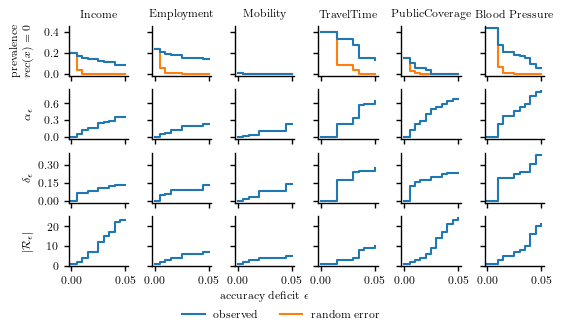

In [80]:
# tasks_to_plot = [
#     task
#     for task in TASKS
#     if task not in ["BRFSS_Diabetes", "ACSMobility", "ACSTravelTime"]
# ]
tasks_to_plot = [task for task in TASKS if task != "BRFSS_Diabetes"]

measures = [
    "no_recourse",
    "ambiguity",
    "discrepancy",
    "num_models",
]

fig_width = plt.rcParams["figure.figsize"][0]
fig_height = (1.6 if len(measures)==3 else 3)  # plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    len(measures),
    len(tasks_to_plot),
    figsize=(fig_width, fig_height),
    constrained_layout=True,
    sharey="row",
    sharex=True,
)


def plot_no_recourse(ax, data):
    ax.step(
        data["eps"],
        data["random_error"],
        where="post",
        color="C1",
        label="random error",
    )
    ax.step(
        data["eps"],
        data["observed"],
        where="post",
        color="C0",
        label="observed",
    )


def plot_measure(ax, data, measure):
    ax.step(data["eps"], data[measure], where="post", color="C0")


for m, measure in enumerate(measures):
    ymin = 100
    ymax = 0
    for t, task in enumerate(tasks_to_plot):
        ax = axs[m, t]
        if len(no_recourse[task]) == 0:
            ax.set_axis_off()
            continue
        else:
            if measure == "no_recourse":
                plot_no_recourse(ax, no_recourse[task])
            else:
                plot_measure(ax, multiplicity_measures[task], measure)
        if m == 0:
            # column titles
            ax.set_title(task.replace("ACS", "").replace("BRFSS", "").replace("_", " "))
    
    ylabels={"no_recourse": "prevalence\n" "$rec(x)=0$", "ambiguity":r'$\alpha_{\epsilon}$', "discrepancy":"$\delta_{\epsilon}$", 'num_models': "$|\mathcal{R_\epsilon}|$"}
    axs[m, 0].set_ylabel(ylabels.get(measure, measure))


axs[-1, len(tasks_to_plot) // 2 - 1].set_xlabel(r"accuracy deficit $\epsilon$")
for ax in axs.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune="both"))
fig.align_ylabels(axs[:, 0])

#legend
desired_order = ["observed", "random error", "random prediction", "monoculture"]
handles, labels = axs[0, 0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    ncol=len(ordered_labels),
    bbox_to_anchor=(0.5, -0.08),
    frameon=False, 
    edgecolor="black",  
    fancybox=True,
) 

file_name = build_filename('no-recourse-multiplicity')

for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [81]:
m = no_recourse[task]["num_models"][
    np.where(no_recourse[task]["eps"] == 0.01)[0][0]
]
df[df["task"] == "ACSIncome"].sort_values(
    by="balanced_accuracy", ascending=False
).iloc[:m]

,task,model,is_inst,threshold_fitted,threshold,accuracy,balanced_accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path,fpr,fnr
36,ACSIncome,gpt-4.1,0,1,3.927864e-07,0.787233,0.783722,979224005,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-gpt-4.1/gp...,results/folktexts/0-bullet-is/model-gpt-4.1/gp...,0.202990,0.229566
93,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,9.992916e-01,0.788483,0.783635,364117336,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,0.198019,0.234710
58,ACSIncome,meta-llama--Meta-Llama-3-70B-Instruct,1,1,9.740795e-01,0.775903,0.780935,2479635274,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,0.238108,0.200023


In [82]:
# latex table
print(eps)
print(num_shots)
output = f"{'task':20} & M &\t {'ambiguity':12} & {'discrepancy':12}\\\\"
for task in tasks_to_plot:
    output +=  f"\n{task.replace('_', ' '):20} & {no_recourse[task]['num_models'][-1]} & \t{multiplicity_measures[task]['ambiguity'][-1]:.2f} & \t\t{multiplicity_measures[task]['discrepancy'][-1]:.2f}\\\\"
print(output)

with open(FIGURES_PAPER_DIR/ (build_filename('mulitiplicity_table')+'.txt'), "w") as file:
    file.write(output)

0.05
0
task                 & M &	 ambiguity    & discrepancy \\
ACSIncome            & 23 & 	0.37 & 		0.14\\
ACSEmployment        & 7 & 	0.24 & 		0.13\\
ACSMobility          & 5 & 	0.23 & 		0.14\\
ACSTravelTime        & 10 & 	0.64 & 		0.28\\
ACSPublicCoverage    & 24 & 	0.68 & 		0.23\\
BRFSS Blood Pressure & 21 & 	0.81 & 		0.39\\
